Refitting the dose-response relationships for 5-FC and cytosine, using a 5-parameters logitstic curve, instead of the Hill equation.

Growth rates will be computed two ways: 1) Max log rate and 2) slope of a linear regression on log(OD)

In [3]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import scipy.optimize as optimize
import scipy.stats as stats
import statsmodels.api as sm
from scipy.optimize import curve_fit
from numpy.lib.stride_tricks import sliding_window_view
#from matplotlib.backends.backend_pdf import PdfPages

## Calculating growth rates

### Defining functions

In [79]:
def merged_growth_epoch(data_epoch, config_file):
    """Processing the reformatted Epoch data to add information on each well"""
    data_df = pd.read_csv(data_epoch)

    data_ready = pd.melt(data_df, id_vars=['Well'], value_vars=data_df.columns[1:], var_name='time', value_name= 'OD')
    data_ready['time'] = data_ready['time'].str.slice(0, -1)

    # Importing the config file
    plate_config = pd.read_csv(config_file)
    plate_config = plate_config.dropna(axis=1, how='all')

    # Making a dataframe combining the data with the strain and condition annotations
    data_merged = data_ready.merge(plate_config, on='Well')

    return data_merged

In [7]:
# Functions to perform the linear regression on log(OD)
# Defining functions
def fit_on_exp(data, OD_col, OD_scale, time_col, cut_time):
    """Function to identify the exponential part of a growth curve, allowing to estimate its slope"""
    data_subset = data[data[time_col] >= cut_time].copy().reset_index(drop=True)
    data_subset = data_subset.sort_values(by=time_col).reset_index(drop=True)  # Make sure that time is sorted
    data_subset['OD_calc'] = data_subset[OD_col] * OD_scale

    # Identify the exponential part of the curve
    deriv_series = np.median(sliding_window_view(np.diff(data_subset['OD_calc']), 3), axis=1)
    time_index = np.argmax(deriv_series) + 3  # Because the 0 has been removed by the diff calculation
                                              # And sliding window then removed the first two values
    time_max = data_subset[time_col][time_index]

    # If time_max is too early of too late, a value of 10 is instead selected
    # Very early T_max are artefactual, while very late ones are due to a second growth phase in low cytosine concentrations
    if (time_max < 3) or (time_max > 30):
        time_max = 10

    # Selecting only the exponential part of the curve
    exp_subset = data_subset[data_subset[time_col] <= time_max].copy()

    return exp_subset, time_max


def log_lin_fit(data_exp, OD_col, time_col):

    exp_subset = data_exp.copy()

    # Fit a line over the log(OD) data, only for the exponential part of the curve
    exp_subset = exp_subset[[time_col, OD_col]].copy().sort_values(by=time_col).reset_index(drop=True)
    exp_subset['Log_OD'] = np.log(exp_subset[OD_col])
    exp_subset = exp_subset.infer_objects()

    # Prepare X and Y vectors for linear regression (OLS)
    X_time = exp_subset[time_col].copy()
    Y_od = exp_subset['Log_OD']
    X_time = sm.add_constant(X_time)

    model_od = sm.OLS(Y_od, X_time)
    fit_od = model_od.fit()
    mu_log = fit_od.params[time_col]
    intercept_od = fit_od.params['const']

    return mu_log, intercept_od
    

def get_log_slope(data, well, well_col, OD_col, OD_scale, time_col, cut_time):
    
    well_subset = data[data[well_col] == well].copy().reset_index(drop=True)

    # Identify the exponential part
    exp_data = fit_on_exp(well_subset, OD_col, OD_scale, time_col, cut_time)[0]

    # Perform the linear fit over log(OD)
    mu_log = log_lin_fit(exp_data, 'OD_calc', time_col)[0]
    
    return mu_log

In [8]:
# Function to obtain the max_log growth rate
def get_max_log_deriv(data, well, well_col, OD_col, OD_scale, time_col, time_bounds):
    """Computing exponential growth rates as the maximum derivative of log(OD). This function assumes that
    measurements are equally spaced in time."""
    
    well_subset = data[data[well_col] == well].copy().reset_index(drop=True)
    well_subset = well_subset[well_subset[time_col] >= time_bounds[0]].copy().reset_index(drop=True)
    well_subset = well_subset[well_subset[time_col] <= time_bounds[1]].copy().reset_index(drop=True)
    well_subset['OD_norm'] = well_subset[OD_col]*OD_scale
    well_subset['Log_OD'] = np.log(well_subset['OD_norm'])

    time_int = np.median(np.diff(well_subset[time_col]))
    top10_log = well_subset['Log_OD'].diff().nlargest(10) / time_int

    slope_log= np.median(top10_log)
    sd_log = np.std(top10_log)

    return slope_log, sd_log

In [9]:
# Function to compute max linear growth rate as in Després et al. (2022)
# Adding time bounds as with max_log_rate, to minimize noise

def get_derivative_growth_rate(data, well, well_col, OD_col, OD_scale, time_col, time_bounds):
    
    well_subset = data[data[well_col] == well].copy().reset_index(drop=True)
    well_subset = well_subset[well_subset[time_col] >= time_bounds[0]].copy().reset_index(drop=True)
    well_subset = well_subset[well_subset[time_col] <= time_bounds[1]].copy().reset_index(drop=True)
    well_subset['OD_norm'] = well_subset[OD_col]*OD_scale
    well_subset['OD_diff'] = well_subset['OD_norm'].diff()

    # Inferrring the time interval between measurements
    time_int = np.median(np.diff(well_subset[time_col]))
    
    # Computing derivatives and inferring max growth rate
    top10_indexes = well_subset['OD_diff'].nlargest(10).index
    top10_subset = well_subset.iloc[np.r_[top10_indexes], :].copy()
    top10_subset['OD_deriv'] = top10_subset['OD_diff'] / time_int

    deriv_growth = np.median(top10_subset['OD_deriv'])
    sd_deriv = np.std(top10_subset['OD_deriv'])

    return deriv_growth, sd_deriv

### Growth in 5-FC

In [11]:
plate_config = pd.read_csv("Data_for_SFigs/config_40_23_09_15_SA.csv")
plate_data = pd.read_csv("Data_for_SFigs/Tecan40_23_09_17_SA.csv", encoding='unicode_escape')

In [12]:
# Reformatting the growth data
temp_5FC = plate_data.iloc[0, 1:].copy()  # Separating the temperature timeseries, in case we want to use it later
OD_5FC = plate_data.iloc[1:, :].copy()
OD_5FC = OD_5FC.dropna(subset=['Unnamed: 0']).reset_index(drop=True).copy()
OD_5FC = OD_5FC.rename(columns={'Unnamed: 0': 'Well'})

# Reformatting the well column
OD_5FC['Well'] = OD_5FC['Well'].apply(lambda x: x[0]+'0'+x[1] if len(x)==2 else x)
plate_config = plate_config.rename(columns={'well': 'Well'})
plate_config['Well'] = plate_config['Well'].apply(lambda x: x[0]+'0'+x[1] if len(x)==2 else x)

In [13]:
# Obtaining blank-adjusted OD data
# Because there were no empty wells, the median blank from other
# growth assays in TECAN readers is used (from FCY1_fit_function)

# Reformatting the df and the 'time' column
OD_5FC = OD_5FC[OD_5FC['Well'] != 'A01'].copy().reset_index(drop=True)  # One well is missing from the data ?!?
OD_5FC = pd.melt(OD_5FC, id_vars=['Well'], value_vars=OD_5FC.columns[1:], var_name='time', value_name= 'OD')

data_5FC = pd.merge(plate_config, OD_5FC, on=['Well'], how='right')
data_5FC['time'] = data_5FC['time'].apply(lambda x: int(x[:-1]))
data_5FC = data_5FC.infer_objects()
data_5FC = data_5FC.astype({'OD': 'float64'})
data_5FC['Time (hours)'] = data_5FC['time'] / 3600

# Normalizing using previous blank measurements
med_blanks = 0.08428125
data_5FC['OD_adj'] = data_5FC['OD'] - med_blanks

In [14]:
# Preparing a df to store the growth rates
rates_5FC = data_5FC[['Well', 'strain', 'Replicate', 'condition']].copy().drop_duplicates()
rates_5FC = rates_5FC[rates_5FC['strain'] != 'Blank'].copy().reset_index(drop=True)

In [15]:
# Computing the growth rates, using only blank-adjusted OD data
rates_5FC['Max_lin_rate'] = rates_5FC['Well'].apply(lambda x: get_derivative_growth_rate(data_5FC, x, 'Well', 'OD_adj', 5, 'Time (hours)', (2, 30))[0])
rates_5FC['Max_log_rate'] = rates_5FC['Well'].apply(lambda x: get_max_log_deriv(data_5FC, x, 'Well', 'OD_adj', 5, 'Time (hours)', (2, 30))[0])
rates_5FC['exp_rate'] = rates_5FC['Well'].apply(lambda x: get_log_slope(data_5FC, x, 'Well', 'OD_adj', 5, 'Time (hours)', 2))

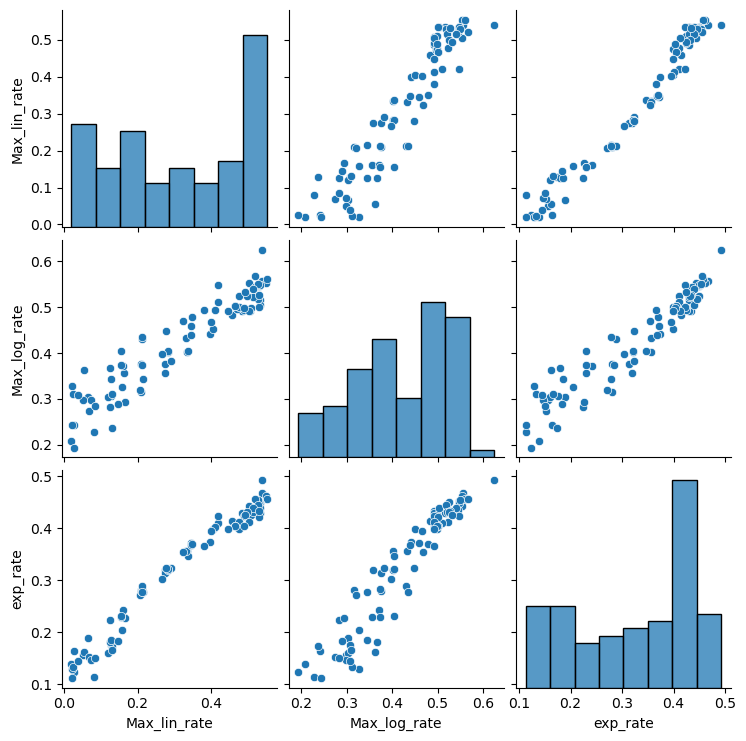

In [16]:
# Looking quickly at the correlations
sns.pairplot(rates_5FC[['Max_lin_rate', 'Max_log_rate', 'exp_rate']])

The exp_rate and the max_lin_rate are very similar...

### Growth in cytosine

In [19]:
plate_config_cy = pd.read_csv("Data_for_SFigs/IC50_cytosine_24-04/Plate1_config_df.csv")
plate_data_cy = pd.read_csv("Data_for_SFigs/IC50_cytosine_24-04/tecan_40_24_04_07_SA.csv", encoding='unicode_escape')

In [20]:
# Reformatting the growth data
temp_cyto = plate_data_cy.iloc[0, 1:].copy()  # Separating the temperature timeseries, in case we want to use it later
OD_cyto = plate_data_cy.iloc[1:, :].copy()
OD_cyto = OD_cyto.dropna(subset=['Unnamed: 0']).reset_index(drop=True).copy()
OD_cyto = OD_cyto.rename(columns={'Unnamed: 0': 'Well'})

# Reformatting the well column
OD_cyto['Well'] = OD_cyto['Well'].apply(lambda x: x[0]+'0'+x[1] if len(x)==2 else x)
plate_config_cy = plate_config_cy.rename(columns={'well': 'Well'})
plate_config_cy['Well'] = plate_config_cy['Well'].apply(lambda x: x[0]+'0'+x[1] if len(x)==2 else x)

In [21]:
# Obtaining blank-adjusted OD data
# Because there were no empty wells, the median blank from other
# growth assays in TECAN readers is used (from FCY1_fit_function)

# Reformatting the df and the 'time' column
OD_cyto = OD_cyto[OD_cyto['Well'] != 'A01'].copy().reset_index(drop=True)  # One well is missing from the data ?!?
OD_cyto = pd.melt(OD_cyto, id_vars=['Well'], value_vars=OD_cyto.columns[1:], var_name='time', value_name= 'OD')

data_cyto = pd.merge(plate_config_cy, OD_cyto, on=['Well'], how='right')
data_cyto['time'] = data_cyto['time'].apply(lambda x: int(x[:-1]))
data_cyto = data_cyto.infer_objects()
data_cyto = data_cyto.astype({'OD': 'float64'})
data_cyto['Time (hours)'] = data_cyto['time'] / 3600

# Normalizing using previous blank measurements
med_blanks = 0.08428125
data_cyto['OD_adj'] = data_cyto['OD'] - med_blanks

In [22]:
# Preparing a df to store the growth rates
rates_cyto = data_cyto[['Well', 'strain', 'Replicate', 'Cytosine (uM)']].copy().drop_duplicates()
rates_cyto = rates_cyto[rates_cyto['strain'] != 'Blank'].copy().reset_index(drop=True)

In [23]:
# Computing the growth rates, using only blank-adjusted OD data
rates_cyto['Max_lin_rate'] = rates_cyto['Well'].apply(lambda x: get_derivative_growth_rate(data_cyto, x, 'Well', 'OD_adj', 5, 'Time (hours)', (2, 30))[0])
rates_cyto['Max_log_rate'] = rates_cyto['Well'].apply(lambda x: get_max_log_deriv(data_cyto, x, 'Well', 'OD_adj', 5, 'Time (hours)', (2, 30))[0])
rates_cyto['exp_rate'] = rates_cyto['Well'].apply(lambda x: get_log_slope(data_cyto, x, 'Well', 'OD_adj', 5, 'Time (hours)', 2))

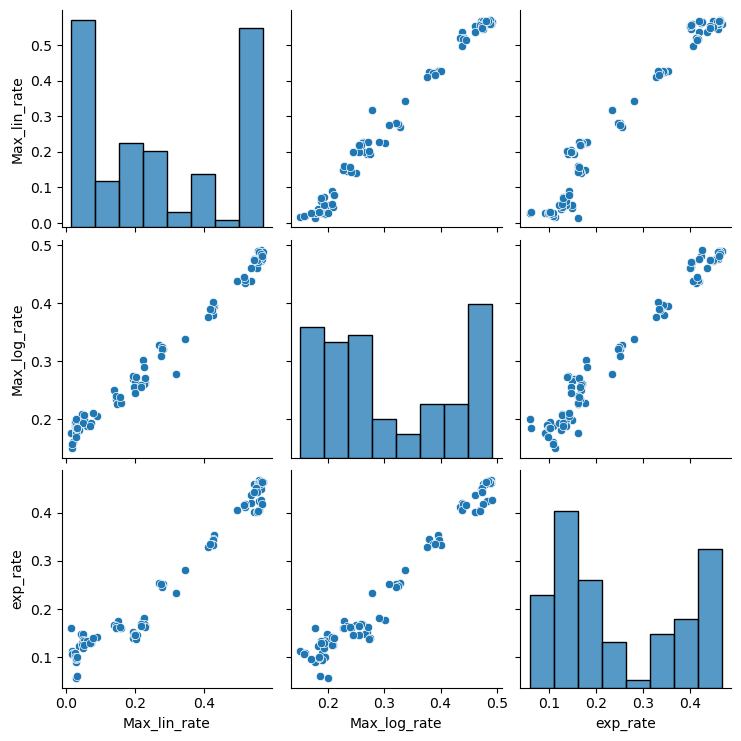

In [24]:
# Looking quickly at the correlations
sns.pairplot(rates_cyto[['Max_lin_rate', 'Max_log_rate', 'exp_rate']])

## Fitting dose-response relationships

Growth rates, rather than relative growth or inhibition will be used for the fit.

### Defining functions

In [28]:
# Defining the five-parameter logistic function

def param_5_logit(t, A, B, D, x_mid, S):
    """Alternative version of the 5-parameter logistic function
    A = Value of horizontal asymptote at minus infinity
    D = Value of horizontal asymptote at plus infinity
    B = Growth rate before x_mid (not exactly the inflexion point)
    x_mid = t value at the midpoint of the curve (not exactly the inflexion point)
    S = Asymmetry term"""

    return (A + (D - A) / ((1 + np.exp(np.log(2**(1/S) - 1) + B * (x_mid - t)))**S))


# Defining the Hill equation
def hill_equation(x, E, n):
    
    return 1/(1+((E/x)**n))

### Fitting the relationships for 5-FC

In [30]:
# First need to add the uM concentrations
conc_dict = {'1/64 x IC50': 9.14/64, '8 x IC50': 9.14*8, '16 x IC50': 9.14*16, '32 x IC50': 9.14*32, '1/32 x IC50': 9.14/32,
             '1/16 x IC50': 9.14/16, '1/8 x IC50': 9.14/8, '1/4 x IC50': 9.14/4, '1/2 x IC50': 9.14/2, '1 x IC50': 9.14,
             '2 x IC50': 9.14*2, '4 x IC50': 9.14*4, 'No 5FC': 0}

rates_5FC['5FC concentration'] = rates_5FC['condition'].apply(lambda x: conc_dict[x])
rates_5FC['Log2 5FC concentration'] = np.log2(rates_5FC['5FC concentration'])

F:\Anaconda_SA\envs\FCY1prom_final\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [31]:
# Preparing a df to store the parameters
dose_params_5FC = pd.DataFrame(columns=['strain', 'params_lin_rate_Hill', 'params_lin_rate_logit',
                                       'params_Max_log_Hill', 'params_Max_log_logit',
                                       'params_exp_rate_Hill', 'params_exp_rate_logit'])
dose_params_5FC['strain'] = rates_5FC['strain'].unique()

In [32]:
# Performing all the fits
for row_id in dose_params_5FC.index:
    current_strain = dose_params_5FC.at[row_id, 'strain']
    data_strain = rates_5FC[rates_5FC['strain'] == current_strain].copy().reset_index(drop=True)
    data_strain = data_strain[data_strain['condition'] != 'No 5FC'].copy().reset_index(drop=True)

    # Fits for Hill equation
    # Of course, these cannot work when using growth rates
    #dose_params_5FC['params_lin_rate_Hill'] = optimize.curve_fit(hill_equation, data_strain['Log2 5FC concentration'],
                                                                 #data_strain['Max_lin_rate'])[0]
    #dose_params_5FC['params_Max_log_Hill'] = optimize.curve_fit(hill_equation, data_strain['Log2 5FC concentration'],
                                                                #data_strain['Max_log_rate'])[0]
    #dose_params_5FC['params_exp_rate_Hill'] = optimize.curve_fit(hill_equation, data_strain['Log2 5FC concentration'],
                                                                 #data_strain['exp_rate'])[0]
    # Fitting the 5-param logistic model
    dose_params_5FC.at[row_id, 'params_lin_rate_logit'] = optimize.curve_fit(param_5_logit, data_strain['5FC concentration'],
                                                                             data_strain['Max_lin_rate'], method='trf')[0]
    dose_params_5FC.at[row_id, 'params_Max_log_logit'] = optimize.curve_fit(param_5_logit, data_strain['5FC concentration'],
                                                                            data_strain['Max_log_rate'], method='trf')[0]
    dose_params_5FC.at[row_id, 'params_exp_rate_logit'] = optimize.curve_fit(param_5_logit, data_strain['5FC concentration'],
                                                                             data_strain['exp_rate'], method='trf')[0]

In [33]:
dose_params_5FC

,strain,params_lin_rate_Hill,params_lin_rate_logit,params_Max_log_Hill,params_Max_log_logit,params_exp_rate_Hill,params_exp_rate_logit
0,BY4742,NaN,"[129.19170702058545, 0.07859364453579454, 0.08...",NaN,"[77.91877439804671, 0.08307749485537197, 0.290...",NaN,"[83.72633045015, 0.05250297334388966, 0.166154..."
1,AKD1123,NaN,"[129.56851158493268, 0.0844163829469959, 0.090...",NaN,"[96.85636511973911, 0.07762945800244635, 0.292...",NaN,"[97.52200793136458, 0.03880804068338303, 0.141..."
2,F4-AKD1123,NaN,"[142.63046026292182, 0.07787907356063782, 0.08...",NaN,"[73.27098543578828, 0.034178165859459944, 0.29...",NaN,"[108.47641111440952, 0.03832884999628732, 0.14..."


In [34]:
# Comparing the fits to the data
conc_linspace = np.linspace(np.min(np.sort(rates_5FC['5FC concentration'])), np.max(rates_5FC['5FC concentration']), 50)
conc_logspace = np.logspace(np.log2(np.sort(rates_5FC['5FC concentration'].unique())[1]), np.log2(np.max(rates_5FC['5FC concentration'])), num=50, base=2)


# For AKD1123 to begin
fit_params_lin = dose_params_5FC[dose_params_5FC['strain'] == 'AKD1123']['params_lin_rate_logit'].values[0]
fit_lin_1123 = param_5_logit(conc_logspace, fit_params_lin[0], fit_params_lin[1], fit_params_lin[2],
                            fit_params_lin[3], fit_params_lin[4])
fit_params_log = dose_params_5FC[dose_params_5FC['strain'] == 'AKD1123']['params_Max_log_logit'].values[0]
fit_log_1123 = param_5_logit(conc_logspace, fit_params_log[0], fit_params_log[1], fit_params_log[2],
                             fit_params_log[3], fit_params_log[4])
fit_params_exp = dose_params_5FC[dose_params_5FC['strain'] == 'AKD1123']['params_exp_rate_logit'].values[0]
fit_exp_1123 = param_5_logit(conc_logspace, fit_params_exp[0], fit_params_exp[1], fit_params_exp[2],
                             fit_params_exp[3], fit_params_exp[4])

Text(0.5, 1.0, 'AKD1123 using exp rate')

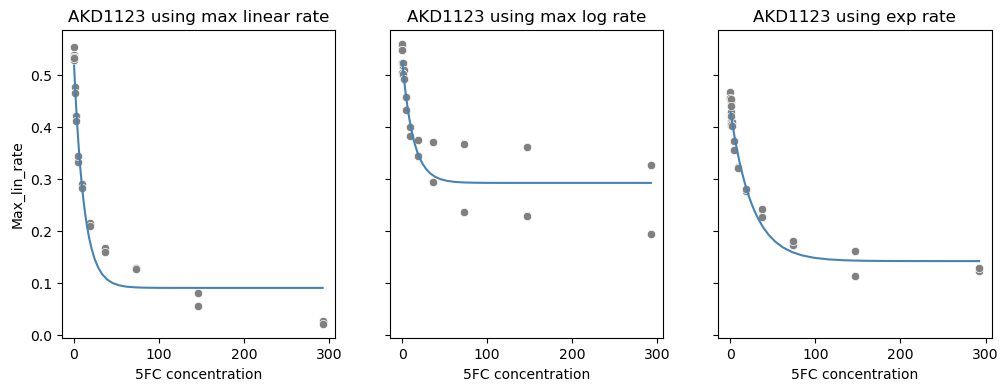

In [35]:
# Plotting the three curves
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey='row')

# First plot
sns.scatterplot(data=rates_5FC[rates_5FC['strain'] == 'AKD1123'], x='5FC concentration', y='Max_lin_rate', c='grey', ax=axs[0])
axs[0].plot(conc_logspace, fit_lin_1123, c='steelblue')
axs[0].set_title('AKD1123 using max linear rate')

# Second plot
sns.scatterplot(data=rates_5FC[rates_5FC['strain'] == 'AKD1123'], x='5FC concentration', y='Max_log_rate', c='grey', ax=axs[1])
axs[1].plot(conc_logspace, fit_log_1123, c='steelblue')
axs[1].set_title('AKD1123 using max log rate')

# Second plot
sns.scatterplot(data=rates_5FC[rates_5FC['strain'] == 'AKD1123'], x='5FC concentration', y='exp_rate', c='grey', ax=axs[2])
axs[2].plot(conc_logspace, fit_exp_1123, c='steelblue')
axs[2].set_title('AKD1123 using exp rate')

Text(0.5, 1.0, 'AKD1123 using exp rate')

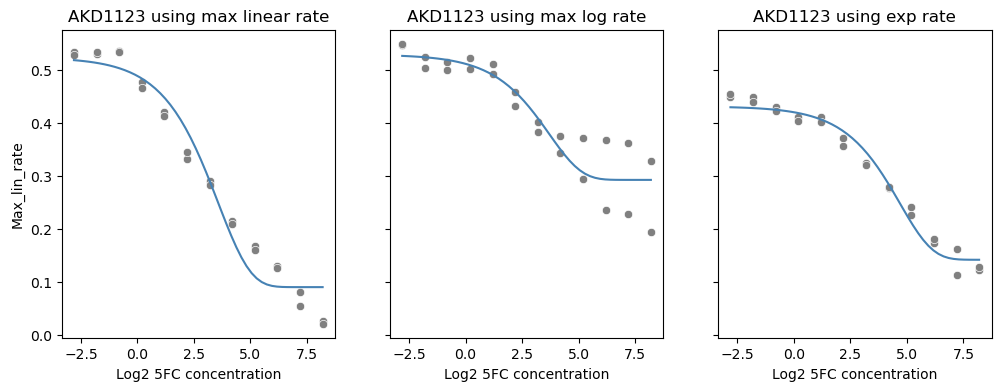

In [36]:
# Same, but log-scaled
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey='row')

# First plot
sns.scatterplot(data=rates_5FC[rates_5FC['strain'] == 'AKD1123'], x='Log2 5FC concentration', y='Max_lin_rate', c='grey', ax=axs[0])
axs[0].plot(np.log2(conc_logspace), fit_lin_1123, c='steelblue')
axs[0].set_title('AKD1123 using max linear rate')

# Second plot
sns.scatterplot(data=rates_5FC[rates_5FC['strain'] == 'AKD1123'], x='Log2 5FC concentration', y='Max_log_rate', c='grey', ax=axs[1])
axs[1].plot(np.log2(conc_logspace), fit_log_1123, c='steelblue')
axs[1].set_title('AKD1123 using max log rate')

# Second plot
sns.scatterplot(data=rates_5FC[rates_5FC['strain'] == 'AKD1123'], x='Log2 5FC concentration', y='exp_rate', c='grey', ax=axs[2])
axs[2].plot(np.log2(conc_logspace), fit_exp_1123, c='steelblue')
axs[2].set_title('AKD1123 using exp rate')

We obtain a nice sigmoid relationship with "exp_rate", which we will use for downstream analyses

### Fitting the relationships for cytosine

In [39]:
# Adding a column for log2 cytosine concentration
rates_cyto['Log2 cytosine'] = np.log2(rates_cyto['Cytosine (uM)'])

In [40]:
rates_cyto.columns

Index(['Well', 'strain', 'Replicate', 'Cytosine (uM)', 'Max_lin_rate',
       'Max_log_rate', 'exp_rate', 'Log2 cytosine'],
      dtype='object')

In [41]:
# Preparing a df to store the parameters
dose_params_cyto = pd.DataFrame(columns=['strain', 'params_lin_rate_logit',
                                         'params_Max_log_logit', 'params_exp_rate_logit'])
dose_params_cyto['strain'] = rates_cyto['strain'].unique()

In [42]:
# Performing the fits
for row_id in dose_params_cyto.index:
    current_strain = dose_params_cyto.at[row_id, 'strain']
    data_strain = rates_cyto[rates_cyto['strain'] == current_strain].copy().reset_index(drop=True)
    data_strain = data_strain.dropna(subset=['Cytosine (uM)']).copy().reset_index(drop=True)

    # Fitting the 5-param logistic model
    dose_params_cyto.at[row_id, 'params_lin_rate_logit'] = optimize.curve_fit(param_5_logit, data_strain['Cytosine (uM)'],
                                                                              data_strain['Max_lin_rate'], method='trf')[0]
    dose_params_cyto.at[row_id, 'params_Max_log_logit'] = optimize.curve_fit(param_5_logit, data_strain['Cytosine (uM)'],
                                                                            data_strain['Max_log_rate'], method='trf')[0]
    dose_params_cyto.at[row_id, 'params_exp_rate_logit'] = optimize.curve_fit(param_5_logit, data_strain['Cytosine (uM)'],
                                                                             data_strain['exp_rate'], method='trf')[0]

C:\Users\tiger\AppData\Local\Temp\ipykernel_39580\1335156117.py:11: RuntimeWarning: invalid value encountered in log
  return (A + (D - A) / ((1 + np.exp(np.log(2**(1/S) - 1) + B * (x_mid - t)))**S))


In [50]:
# Comparing the fits to the data
cyto_linspace = np.linspace(np.min(np.sort(rates_cyto['Cytosine (uM)'])), np.max(rates_cyto['Cytosine (uM)']), 50)
cyto_logspace = np.logspace(np.log2(np.min(rates_cyto['Cytosine (uM)'])), np.log2(np.max(rates_cyto['Cytosine (uM)'])), num=50, base=2)


# For AKD1123 to begin
fit_params_lin_cyto = dose_params_cyto[dose_params_cyto['strain'] == 'AKD1123']['params_lin_rate_logit'].values[0]
fit_lin_1123_cyto = param_5_logit(cyto_logspace, fit_params_lin_cyto[0], fit_params_lin_cyto[1], fit_params_lin_cyto[2],
                                  fit_params_lin_cyto[3], fit_params_lin_cyto[4])
fit_params_log_cyto = dose_params_cyto[dose_params_cyto['strain'] == 'AKD1123']['params_Max_log_logit'].values[0]
fit_log_1123_cyto = param_5_logit(cyto_logspace, fit_params_log_cyto[0], fit_params_log_cyto[1], fit_params_log_cyto[2],
                                  fit_params_log_cyto[3], fit_params_log_cyto[4])
fit_params_exp_cyto = dose_params_cyto[dose_params_cyto['strain'] == 'AKD1123']['params_exp_rate_logit'].values[0]
fit_exp_1123_cyto = param_5_logit(cyto_logspace, fit_params_exp_cyto[0], fit_params_exp_cyto[1], fit_params_exp_cyto[2],
                                  fit_params_exp_cyto[3], fit_params_exp_cyto[4])

Text(0.5, 1.0, 'AKD1123 using exp rate')

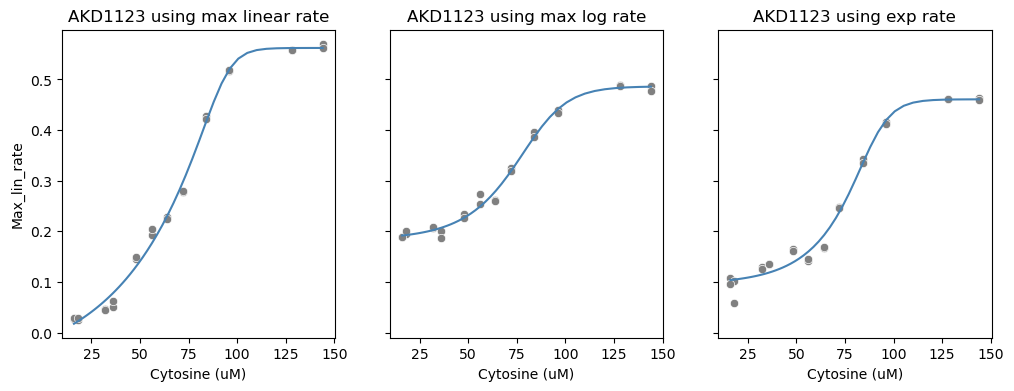

In [52]:
# Plotting the three curves
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey='row')

# First plot
sns.scatterplot(data=rates_cyto[rates_cyto['strain'] == 'AKD1123'], x='Cytosine (uM)', y='Max_lin_rate', c='grey', ax=axs[0])
axs[0].plot(cyto_logspace, fit_lin_1123_cyto, c='steelblue')
axs[0].set_title('AKD1123 using max linear rate')

# Second plot
sns.scatterplot(data=rates_cyto[rates_cyto['strain'] == 'AKD1123'], x='Cytosine (uM)', y='Max_log_rate', c='grey', ax=axs[1])
axs[1].plot(cyto_logspace, fit_log_1123_cyto, c='steelblue')
axs[1].set_title('AKD1123 using max log rate')

# Second plot
sns.scatterplot(data=rates_cyto[rates_cyto['strain'] == 'AKD1123'], x='Cytosine (uM)', y='exp_rate', c='grey', ax=axs[2])
axs[2].plot(cyto_logspace, fit_exp_1123_cyto, c='steelblue')
axs[2].set_title('AKD1123 using exp rate')

Text(0.5, 1.0, 'AKD1123 using exp rate')

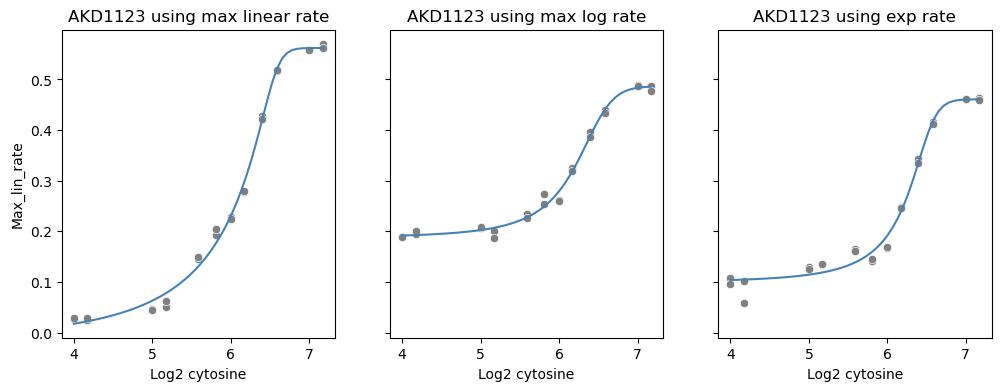

In [54]:
# Same thing but log-scaled
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey='row')

# First plot
sns.scatterplot(data=rates_cyto[rates_cyto['strain'] == 'AKD1123'], x='Log2 cytosine', y='Max_lin_rate', c='grey', ax=axs[0])
axs[0].plot(np.log2(cyto_logspace), fit_lin_1123_cyto, c='steelblue')
axs[0].set_title('AKD1123 using max linear rate')

# Second plot
sns.scatterplot(data=rates_cyto[rates_cyto['strain'] == 'AKD1123'], x='Log2 cytosine', y='Max_log_rate', c='grey', ax=axs[1])
axs[1].plot(np.log2(cyto_logspace), fit_log_1123_cyto, c='steelblue')
axs[1].set_title('AKD1123 using max log rate')

# Second plot
sns.scatterplot(data=rates_cyto[rates_cyto['strain'] == 'AKD1123'], x='Log2 cytosine', y='exp_rate', c='grey', ax=axs[2])
axs[2].plot(np.log2(cyto_logspace), fit_exp_1123_cyto, c='steelblue')
axs[2].set_title('AKD1123 using exp rate')

### Repeating the cytosine fit using the most recent (2025-11) data, covering a more comprehensive range of cytosine concentrations

In [81]:
# Importing data for the first cytosine plate
OD_cyto1 = pd.read_csv("Toolbox_IC_25-11-17/Tool_Cyto_IC_Plate1_25-11_21_SA.csv", encoding='unicode_escape')
temp_cyto1 = OD_cyto1[['Time', 'T° 600']].copy()

OD_cyto1 = OD_cyto1.drop(columns=['T° 600']).transpose()
OD_cyto1 = OD_cyto1.rename(columns=OD_cyto1.iloc[0]).iloc[1:]
OD_cyto1.insert(0, 'Well', OD_cyto1.index)
OD_cyto1 = OD_cyto1.reset_index(drop=True)

# Saving the reformatted df
OD_cyto1.to_csv("Toolbox_IC_25-11-17/Tool_Cyto_IC_Plate1_25-11_21_SA_Modified.csv")

In [83]:
# Same with the second plate
OD_cyto2 = pd.read_csv("Toolbox_IC_25-11-17/Tool_Cyto_IC_Plate2_25-11_21_SA.csv", encoding='unicode_escape')
temp_cyto2 = OD_cyto2[['Time', 'T° 600']].copy()

OD_cyto2 = OD_cyto2.drop(columns=['T° 600']).transpose()
OD_cyto2 = OD_cyto2.rename(columns=OD_cyto2.iloc[0]).iloc[1:]
OD_cyto2.insert(0, 'Well', OD_cyto2.index)
OD_cyto2 = OD_cyto2.reset_index(drop=True)

# Saving the reformatted df
OD_cyto2.to_csv("Toolbox_IC_25-11-17/Tool_Cyto_IC_Plate2_25-11_21_SA_Modified.csv")

In [85]:
# Merging with the plate configuration
merged_cyto1 = merged_growth_epoch("Toolbox_IC_25-11-17/Tool_Cyto_IC_Plate1_25-11_21_SA_Modified.csv",
                                   "Toolbox_IC_25-11-17/Plate1_Cyto_25-11-19_df.csv")

merged_cyto2 = merged_growth_epoch("Toolbox_IC_25-11-17/Tool_Cyto_IC_Plate2_25-11_21_SA_Modified.csv",
                                   "Toolbox_IC_25-11-17/Plate2_Cyto_25-11-19_df.csv")

In [87]:
# Preparing dataframes to store the growth rates
rates_cyto1 = merged_cyto1[['Well', 'Strain', 'Clone', 'Condition', 'Rel_growth']].copy().drop_duplicates()
rates_cyto2 = merged_cyto2[['Well', 'Strain', 'Clone', 'Condition', 'Rel_growth']].copy().drop_duplicates()

# Reformatting the "time" column
merged_cyto1['time'] = merged_cyto1['time'].apply(lambda x: int(x.split(':')[0]) + (int(x.split(':')[1]) / 60) + (int(x.split(':')[2]) / 3600))
merged_cyto2['time'] = merged_cyto2['time'].apply(lambda x: int(x.split(':')[0]) + (int(x.split(':')[1]) / 60) + (int(x.split(':')[2]) / 3600))

In [89]:
# Normalizing by the blank OD
blank_cyto1 = np.median(merged_cyto1[(merged_cyto1['Strain'] == 'Blank') & (merged_cyto1['time'] < 0.2)]['OD'])
merged_cyto1['OD_adj'] = merged_cyto1['OD'] - blank_cyto1

blank_cyto2 = np.median(merged_cyto2[(merged_cyto2['Strain'] == 'Blank') & (merged_cyto2['time'] < 0.2)]['OD'])
merged_cyto2['OD_adj'] = merged_cyto2['OD'] - blank_cyto2

# Removing the 'blank' wells, where the calculation of growth rates is nonsensical
rates_cyto1 = rates_cyto1[rates_cyto1['Strain'] != 'Blank'].copy().reset_index(drop=True)
rates_cyto2 = rates_cyto2[rates_cyto2['Strain'] != 'Blank'].copy().reset_index(drop=True)

In [91]:
# Computing the growth rates, using only blank-adjusted OD data
rates_cyto1['Max_lin_rate'] = rates_cyto1['Well'].apply(lambda x: get_derivative_growth_rate(merged_cyto1, x, 'Well', 'OD_adj', 5, 'time', (2, 30))[0])
rates_cyto1['Max_log_rate'] = rates_cyto1['Well'].apply(lambda x: get_max_log_deriv(merged_cyto1, x, 'Well', 'OD_adj', 5, 'time', (2, 30))[0])
rates_cyto1['exp_rate'] = rates_cyto1['Well'].apply(lambda x: get_log_slope(merged_cyto1, x, 'Well', 'OD_adj', 5, 'time', 2))
rates_cyto1['Plate'] = 'Cyto-1'

rates_cyto2['Max_lin_rate'] = rates_cyto2['Well'].apply(lambda x: get_derivative_growth_rate(merged_cyto2, x, 'Well', 'OD_adj', 5, 'time', (2, 30))[0])
rates_cyto2['Max_log_rate'] = rates_cyto2['Well'].apply(lambda x: get_max_log_deriv(merged_cyto2, x, 'Well', 'OD_adj', 5, 'time', (2, 30))[0])
rates_cyto2['exp_rate'] = rates_cyto2['Well'].apply(lambda x: get_log_slope(merged_cyto2, x, 'Well', 'OD_adj', 5, 'time', 2))
rates_cyto2['Plate'] = 'Cyto-2'

# Concatenating the data
rates_cyto_25_11 = pd.concat([rates_cyto1, rates_cyto2]).reset_index(drop=True)

In [94]:
# Converting the expected rel_growth into the uM cytosine concentration
cyto_dict = {'0.0': 3.9849399571523847, '0.025': 21.024623010295468,
             '0.05': 26.084030289245117, '0.1': 32.63468093126321,
             '0.15': 37.490713146782376,
             '0.2': 41.618011456718286, '0.25': 45.36743388128656,
             '0.3': 48.91828154903047, '0.35': 52.383651916871344,
             '0.4': 55.84805873236876, '0.45': 59.38504258333152,
             '0.5': 63.068, '0.6': 71.2213228943382,
             '0.7': 81.31055503274996, '0.8': 95.57334636558929,
             '0.925': 133.9582975302216, '1.0': 500.2982634650052}
rates_cyto_25_11['Rel_growth'] = rates_cyto_25_11['Rel_growth'].astype('str')
rates_cyto_25_11['Cytosine (uM)'] = rates_cyto_25_11['Rel_growth'].apply(lambda x: cyto_dict[str(x)])

In [102]:
# Adding a column for log2 cytosine concentration
rates_cyto_25_11['Log2 cytosine'] = np.log2(rates_cyto_25_11['Cytosine (uM)'])

# Preparing a df to store the parameters
dose_params_cyto_25 = pd.DataFrame(columns=['Strain', 'params_lin_rate_logit',
                                            'params_Max_log_logit', 'params_exp_rate_logit'])
dose_params_cyto_25['Strain'] = rates_cyto_25_11['Strain'].unique()

In [110]:
# Performing the fits
for row_id in dose_params_cyto_25.index:
    current_strain = dose_params_cyto_25.at[row_id, 'Strain']
    if current_strain == 'FCY1 deletion':
        continue
    data_strain = rates_cyto_25_11[rates_cyto_25_11['Strain'] == current_strain].copy().reset_index(drop=True)
    data_strain = data_strain.dropna(subset=['Cytosine (uM)']).copy().reset_index(drop=True)

    # Fitting the 5-param logistic model
    #dose_params_cyto_25.at[row_id, 'params_lin_rate_logit'] = optimize.curve_fit(param_5_logit, data_strain['Cytosine (uM)'],
                                                                                 #data_strain['Max_lin_rate'], method='trf')[0]
    dose_params_cyto_25.at[row_id, 'params_Max_log_logit'] = optimize.curve_fit(param_5_logit, data_strain['Cytosine (uM)'],
                                                                                data_strain['Max_log_rate'], method='trf')[0]
    dose_params_cyto_25.at[row_id, 'params_exp_rate_logit'] = optimize.curve_fit(param_5_logit, data_strain['Cytosine (uM)'],
                                                                                 data_strain['exp_rate'], method='trf')[0]

F:\Anaconda_SA\envs\FCY1prom_final\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\tiger\AppData\Local\Temp\ipykernel_39580\1335156117.py:11: RuntimeWarning: invalid value encountered in log
  return (A + (D - A) / ((1 + np.exp(np.log(2**(1/S) - 1) + B * (x_mid - t)))**S))
F:\Anaconda_SA\envs\FCY1prom_final\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
F:\Anaconda_SA\envs\FCY1prom_final\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [112]:
# Comparing the fits to the data
cyto_linspace_25 = np.linspace(np.min(np.sort(rates_cyto_25_11['Cytosine (uM)'])), np.max(rates_cyto_25_11['Cytosine (uM)']), 50)
cyto_logspace_25 = np.logspace(np.log2(np.min(rates_cyto_25_11['Cytosine (uM)'])), np.log2(np.max(rates_cyto_25_11['Cytosine (uM)'])), num=50, base=2)


# For AKD1123 to begin
fit_params_log_cyto25 = dose_params_cyto_25[dose_params_cyto_25['Strain'] == 'AKD1123']['params_Max_log_logit'].values[0]
fit_log_1123_cyto25 = param_5_logit(cyto_logspace_25, fit_params_log_cyto25[0], fit_params_log_cyto25[1], fit_params_log_cyto25[2],
                                    fit_params_log_cyto25[3], fit_params_log_cyto25[4])
fit_params_exp_cyto25 = dose_params_cyto_25[dose_params_cyto_25['Strain'] == 'AKD1123']['params_exp_rate_logit'].values[0]
fit_exp_1123_cyto25 = param_5_logit(cyto_logspace_25, fit_params_exp_cyto25[0], fit_params_exp_cyto25[1], fit_params_exp_cyto25[2],
                                    fit_params_exp_cyto25[3], fit_params_exp_cyto25[4])

Text(0.5, 1.0, 'AKD1123 using exp rate')

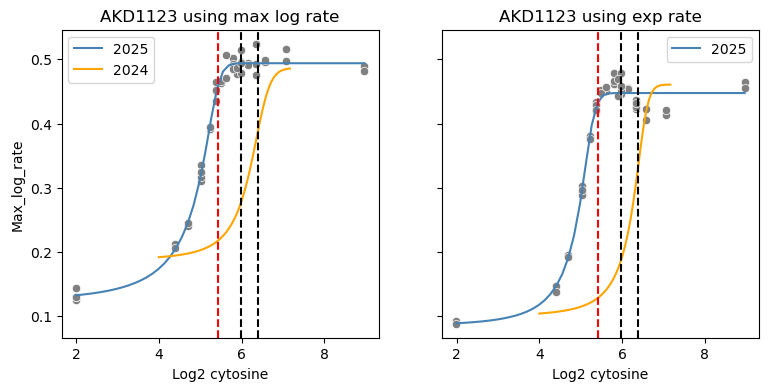

In [132]:
# Plotting the two curves (log-scaled)
fig, axs = plt.subplots(1, 2, figsize=(9, 4), sharey='row')


# Second plot
sns.scatterplot(data=rates_cyto_25_11[rates_cyto_25_11['Strain'] == 'AKD1123'], x='Log2 cytosine', y='Max_log_rate', c='grey', ax=axs[0])
axs[0].plot(np.log2(cyto_logspace_25), fit_log_1123_cyto25, c='steelblue', label='2025')
axs[0].plot(np.log2(cyto_logspace), fit_log_1123_cyto, c='orange', label='2024')
axs[0].legend()
axs[0].axvline(np.log2(84), linestyle='--', c='black')
axs[0].axvline(np.log2(63), linestyle='--', c='black')
axs[0].axvline(np.log2(43), linestyle='--', c='red')
axs[0].set_title('AKD1123 using max log rate')

# Second plot
sns.scatterplot(data=rates_cyto_25_11[rates_cyto_25_11['Strain'] == 'AKD1123'], x='Log2 cytosine', y='exp_rate', c='grey', ax=axs[1])
axs[1].plot(np.log2(cyto_logspace_25), fit_exp_1123_cyto25, c='steelblue', label='2025')
axs[1].plot(np.log2(cyto_logspace), fit_exp_1123_cyto, c='orange')
axs[1].legend()
axs[1].axvline(np.log2(84), linestyle='--', c='black')
axs[1].axvline(np.log2(63), linestyle='--', c='black')
axs[1].axvline(np.log2(43), linestyle='--', c='red')
axs[1].set_title('AKD1123 using exp rate')

There is clearly a shift between the two experiments... The vertical dashed lines suggest that the shift was already present in the original PCR toolbox experiment in cytosine. Otherwise, these three concentrations would have covered a very wide range of fitness values.

Do we also see a shift between 5-FC experiments?

### Repeating the 5-FC fit using the most recent (2025-11) data

In [178]:
# Importing data for the first cytosine plate
OD_5FC_25 = pd.read_csv("Toolbox_IC_25-11-17/FCY1Tool_5FC_508_25-11-17_SA.csv", encoding='unicode_escape')
temp_5FC_25 = OD_5FC_25[['Time', 'T° 600']].copy()

OD_5FC_25 = OD_5FC_25.drop(columns=['T° 600']).transpose()
OD_5FC_25 = OD_5FC_25.rename(columns=OD_5FC_25.iloc[0]).iloc[1:]
OD_5FC_25.insert(0, 'Well', OD_5FC_25.index)
OD_5FC_25 = OD_5FC_25.reset_index(drop=True)

# Saving the reformatted df
OD_5FC_25.to_csv("Toolbox_IC_25-11-17/FCY1Tool_5FC_508_25-11-17_Modified.csv")

# Merging with the plate configuration
merged_5FC_25 = merged_growth_epoch("Toolbox_IC_25-11-17/FCY1Tool_5FC_508_25-11-17_Modified.csv",
                                    "Toolbox_IC_25-11-17/Plate2_5FC_config.csv")

In [179]:
# Preparing a dataframe to store the growth rates
rates_5FC_25 = merged_5FC_25[['Well', 'Strain', 'Clone', 'Culture_type', 'Condition', 'Rel_growth']].copy().drop_duplicates()

merged_5FC_25['time'] = merged_5FC_25['time'].apply(lambda x: int(x.split(':')[0]) + (int(x.split(':')[1]) / 60) + (int(x.split(':')[2]) / 3600))

In [180]:
# Normalizing by the blank OD
blank_5FC_25 = np.median(merged_5FC_25[(merged_5FC_25['Strain'] == 'Blank') & (merged_5FC_25['time'] < 0.2)]['OD'])
merged_5FC_25['OD_adj'] = merged_5FC_25['OD'] - blank_5FC_25

# Removing the 'blank' wells, where the calculation of growth rates is nonsensical
rates_5FC_25 = rates_5FC_25[rates_5FC_25['Strain'] != 'Blank'].copy().reset_index(drop=True)

In [181]:
# Computing the growth rates, using only blank-adjusted OD data
rates_5FC_25['Max_lin_rate'] = rates_5FC_25['Well'].apply(lambda x: get_derivative_growth_rate(merged_5FC_25, x, 'Well', 'OD_adj', 5, 'time', (2, 30))[0])
rates_5FC_25['Max_log_rate'] = rates_5FC_25['Well'].apply(lambda x: get_max_log_deriv(merged_5FC_25, x, 'Well', 'OD_adj', 5, 'time', (2, 30))[0])
rates_5FC_25['exp_rate'] = rates_5FC_25['Well'].apply(lambda x: get_log_slope(merged_5FC_25, x, 'Well', 'OD_adj', 5, 'time', 2))

F:\Anaconda_SA\envs\FCY1prom_final\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
F:\Anaconda_SA\envs\FCY1prom_final\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
F:\Anaconda_SA\envs\FCY1prom_final\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
F:\Anaconda_SA\envs\FCY1prom_final\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
F:\Anaconda_SA\envs\FCY1prom_final\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
F:\Anaconda_SA\envs\FCY1prom_final\Lib\site-packages\pandas\core\arraylike.

In [182]:
# Converting the expected rel_growth into the uM 5-FC concentration
fc_dict = {'0.0': 581, '0.15': 121.3, '0.3': 35.9, '0.4': 19.6, '0.5': 11.2,
           '0.6': 6.4, '0.75': 2.5, '0.9': 0.6, '1.0': 0}
rates_5FC_25['Rel_growth'] = rates_5FC_25['Rel_growth'].astype('str')
rates_5FC_25['5-FC (uM)'] = rates_5FC_25['Rel_growth'].apply(lambda x: fc_dict[str(x)])

In [183]:
# Keeping only the exponential cultures for the WT-like promoters
rates_5FC_WT = rates_5FC_25[rates_5FC_25['Culture_type'] == 'Exponential'].copy().reset_index(drop=True)
rates_5FC_WT = rates_5FC_WT[(rates_5FC_WT['Strain'] == 'pCUP1') | (rates_5FC_WT['Strain'] == 'pTEF1')].copy().reset_index(drop=True)

# Removing the 0 5-FC condition
rates_5FC_WT = rates_5FC_WT[rates_5FC_WT['5-FC (uM)'] != 0.0].copy().reset_index(drop=True)
rates_5FC_WT['Log2 5-FC'] = np.log2(rates_5FC_WT['5-FC (uM)'])

In [184]:
# Fitting the logistic model
logit_5FC_25_max = optimize.curve_fit(param_5_logit, rates_5FC_WT['5-FC (uM)'],
                                      rates_5FC_WT['Max_log_rate'], method='trf')[0]

logit_5FC_25_exp = optimize.curve_fit(param_5_logit, rates_5FC_WT['5-FC (uM)'],
                                      rates_5FC_WT['exp_rate'], method='trf')[0]

In [185]:
# Comparing the fits to the data
FC_logspace_25 = np.logspace(np.log2(np.min(rates_5FC_WT['5-FC (uM)'])), np.log2(np.max(rates_5FC_WT['5-FC (uM)'])), num=50, base=2)


# For AKD1123 to begin
fit_log_wt_fc25 = param_5_logit(FC_logspace_25, logit_5FC_25_max[0], logit_5FC_25_max[1], logit_5FC_25_max[2],
                                logit_5FC_25_max[3], logit_5FC_25_max[4])

fit_exp_wt_fc25 = param_5_logit(FC_logspace_25, logit_5FC_25_exp[0], logit_5FC_25_exp[1], logit_5FC_25_exp[2],
                                logit_5FC_25_exp[3], logit_5FC_25_exp[4])

Text(0.5, 1.0, 'WT-like proms using exp rate')

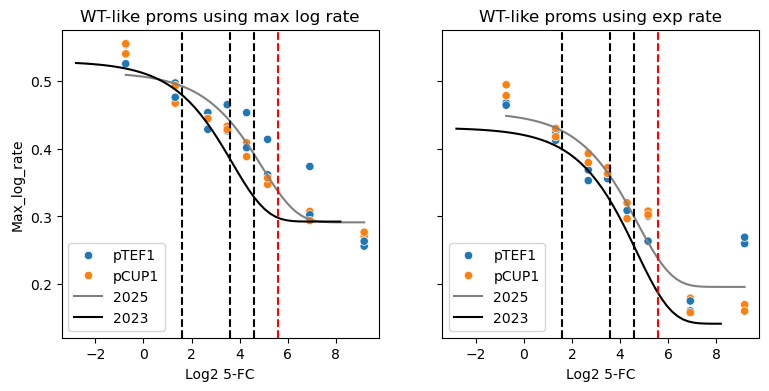

In [200]:
# Plotting the two curves (log-scaled)
fig, axs = plt.subplots(1, 2, figsize=(9, 4), sharey='row')


# First plot
sns.scatterplot(data=rates_5FC_WT, x='Log2 5-FC', y='Max_log_rate', hue='Strain', ax=axs[0])
axs[0].plot(np.log2(FC_logspace_25), fit_log_wt_fc25, c='grey', label='2025')
axs[0].plot(np.log2(conc_logspace), fit_log_1123, c='black', label='2023')
axs[0].legend()
axs[0].axvline(np.log2(3), linestyle='--', c='black')
axs[0].axvline(np.log2(12), linestyle='--', c='black')
axs[0].axvline(np.log2(24), linestyle='--', c='black')
axs[0].axvline(np.log2(48), linestyle='--', c='red')
axs[0].set_title('WT-like proms using max log rate')

# Second plot
sns.scatterplot(data=rates_5FC_WT, x='Log2 5-FC', y='exp_rate', hue='Strain', ax=axs[1])
axs[1].plot(np.log2(FC_logspace_25), fit_exp_wt_fc25, c='grey', label='2025')
axs[1].plot(np.log2(conc_logspace), fit_exp_1123, c='black', label='2023')
axs[1].legend()
axs[1].axvline(np.log2(3), linestyle='--', c='black')
axs[1].axvline(np.log2(12), linestyle='--', c='black')
axs[1].axvline(np.log2(24), linestyle='--', c='black')
axs[1].axvline(np.log2(48), linestyle='--', c='red')
axs[1].set_title('WT-like proms using exp rate')

There is also a slight shift here, but it might simply be due to the fitness difference between the AKD1123 strain (no KanMX cassette) and the PCR toolbox strains (KanMX cassette with the inserted promoter

## Supplementary figure: Comparing the two dose-response curves for AKD1123 (growth rates) and comparing them with reported dose-response curves (Després et al., 2022)

In [273]:
# Translating the two current dose-reponse curves in relative inhibition
# and relative growth (respectively)
max_growth_5FC = np.median(rates_5FC[(rates_5FC['strain'] == 'AKD1123') & (rates_5FC['condition']=='No 5FC')]['exp_rate'])
max_growth_cyto = np.median(rates_cyto_25_11[(rates_cyto_25_11['Strain'] == 'AKD1123') & (rates_cyto_25_11['Rel_growth']=='1.0')]['exp_rate'])

max_lin_5FC = np.median(rates_5FC[(rates_5FC['strain'] == 'AKD1123') & (rates_5FC['condition']=='No 5FC')]['Max_lin_rate'])
max_lin_cyto = np.median(rates_cyto_25_11[(rates_cyto_25_11['Strain'] == 'AKD1123') & (rates_cyto_25_11['Rel_growth']=='1.0')]['Max_lin_rate'])

rates_5FC['Inhib_exp'] = 1 - (rates_5FC['exp_rate'] / max_growth_5FC)
rates_5FC['Inhib_lin'] = 1 - (rates_5FC['Max_lin_rate'] / max_lin_5FC)

rates_cyto_25_11['Growth_exp'] = rates_cyto_25_11['exp_rate'] / max_growth_cyto
rates_cyto_25_11['Growth_lin'] = rates_cyto_25_11['Max_lin_rate'] / max_lin_cyto

In [274]:
# Also converting the fit of the logistic dose-response curves
fit_rel_5FC = 1 - (fit_exp_1123 / max_growth_5FC)

fit_rel_cyto = fit_exp_1123_cyto25 / max_growth_cyto

In [275]:
# Fitting the Hill equation on the linear growth rates
hill_params_5FC = optimize.curve_fit(hill_equation, rates_5FC[rates_5FC['strain'] == 'AKD1123']['5FC concentration'],
                                     rates_5FC[rates_5FC['strain'] == 'AKD1123']['Inhib_lin'])[0]

hill_params_cyto = optimize.curve_fit(hill_equation, rates_cyto_25_11[rates_cyto_25_11['Strain'] == 'AKD1123']['Log2 cytosine'],
                                      rates_cyto_25_11[rates_cyto_25_11['Strain'] == 'AKD1123']['Growth_lin'])[0]

In [276]:
# Generating the data to plot Hill curves, including the ones reported in Després et al.
hill_curve_5FC = hill_equation(conc_logspace, hill_params_5FC[0], hill_params_5FC[1])
hill_5FC_PD = hill_equation(conc_logspace, 9.1395844 , 0.80356349)

hill_curve_cyto = hill_equation(cyto_logspace_25, hill_params_cyto[0], hill_params_cyto[1])
hill_cyto_PD = hill_equation(cyto_logspace_25, 71 , 6.10)

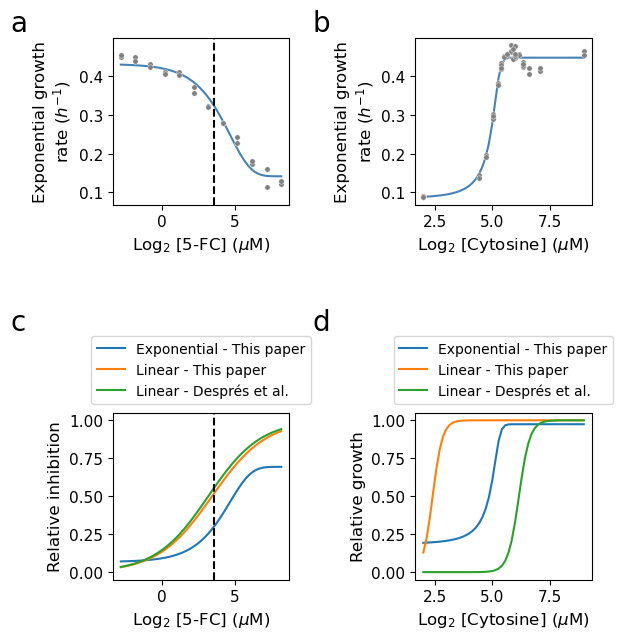

In [886]:
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams['savefig.dpi'] = 600

fig = plt.figure(constrained_layout=False, figsize=(6, 7.5))

# First row, for A and B
gs1 = fig.add_gridspec(nrows=20, ncols=20, left=0.00, right=1.00, bottom=0.5, top=1.00 )
# Second roq, for C and D
gs2 = fig.add_gridspec(nrows=20, ncols=20, left=0.00, right=1.00, bottom=0.00, top=0.5)

# Defining axes
ax1 = fig.add_subplot(gs1[7:16, 2:8])
ax2 = fig.add_subplot(gs1[7:16, 12:18], sharey=ax1)

ax3 = fig.add_subplot(gs2[7:16, 2:8])
ax4 = fig.add_subplot(gs2[7:16, 12:18], sharey=ax3)

# A: dose-response for 5-FC
sns.scatterplot(data=rates_5FC[rates_5FC['strain'] == 'AKD1123'], x='Log2 5FC concentration', y='exp_rate', c='grey', 
                ax=ax1, s=15, zorder=1)
ax1.plot(np.log2(conc_logspace), fit_exp_1123, c='steelblue', zorder=0)
ax1.axvline(x=np.log2(12), c='black', linestyle='--')
ax1.set_ylabel('Exponential growth\nrate 'r"$\left(h^{-1}\right)$")
ax1.set_xlabel(r"Log$_2$ [5-FC] ($\mu$M)")

# B: dose-response for cytosine
sns.scatterplot(data=rates_cyto_25_11[rates_cyto_25_11['Strain'] == 'AKD1123'], x='Log2 cytosine', y='exp_rate', c='grey',
                ax=ax2, s=15, zorder=1)
ax2.plot(np.log2(cyto_logspace_25), fit_exp_1123_cyto25, c='steelblue', zorder=0)
ax2.set_ylabel('Exponential growth\nrate 'r"$\left(h^{-1}\right)$")
ax2.set_xlabel(r"Log$_2$ [Cytosine] ($\mu$M)")

# C: Comparisons for 5-FC
ax3.plot(np.log2(conc_logspace), fit_rel_5FC, label='Exponential - This paper')
ax3.plot(np.log2(conc_logspace), hill_curve_5FC, label='Linear - This paper')
ax3.plot(np.log2(conc_logspace), hill_5FC_PD, label='Linear - Després et al.')
ax3.axvline(x=np.log2(12), c='black', linestyle='--')
ax3.legend(loc='upper center', bbox_to_anchor=(0.5, 1.5))
ax3.set_xlabel(r"Log$_2$ [5-FC] ($\mu$M)")
ax3.set_ylabel('Relative inhibition')


# D: Comparisons for cytosine
ax4.plot(np.log2(cyto_logspace_25), fit_rel_cyto, label='Exponential - This paper')
ax4.plot(np.log2(cyto_logspace_25), hill_curve_cyto, label='Linear - This paper')
ax4.plot(np.log2(cyto_logspace_25), hill_cyto_PD, label='Linear - Després et al.')
ax4.legend(loc='upper center', bbox_to_anchor=(0.5, 1.5))
ax4.set_xlabel(r"Log$_2$ [Cytosine] ($\mu$M)")
ax4.set_ylabel('Relative growth')

# Identifying the plots
ax1.annotate('a', (-74, 125), xycoords='axes points', annotation_clip=False, fontsize=20)
ax2.annotate('b', (-74, 125), xycoords='axes points', annotation_clip=False, fontsize=20)
ax3.annotate('c', (-74, 180), xycoords='axes points', annotation_clip=False, fontsize=20)
ax4.annotate('d', (-74, 180), xycoords='axes points', annotation_clip=False, fontsize=20)

fig = plt.gcf()
fig.savefig(f"Supp_figs/Dose-response_curves.tiff", bbox_inches='tight')

In [943]:
np.median(rates_5FC[(rates_5FC['strain'] == 'AKD1123') & (rates_5FC['condition'] == 'No 5FC')]['exp_rate'])

0.4622713792015909

## Comparing the exp-fitness functions from the same initial relative inhibition or growth

For all concentrations included in the most recent experiments, compute rel inhib/growth from the logistic fits

In [352]:
conc_5FC_df = pd.DataFrame(columns=['5-FC (uM)', 'Log2 5-FC', 'Rel_inhib_WT'])
conc_5FC_df['5-FC (uM)'] = rates_5FC_25['5-FC (uM)'].unique()
conc_5FC_df['Log2 5-FC'] = np.log2(conc_5FC_df['5-FC (uM)'])
conc_5FC_df['Rel_inhib_WT'] = 1 - (param_5_logit(conc_5FC_df['5-FC (uM)'], fit_params_exp[0], fit_params_exp[1], fit_params_exp[2],
                                                 fit_params_exp[3], fit_params_exp[4]) / max_growth_5FC)

conc_cyto_df = pd.DataFrame(columns=['Cytosine (uM)', 'Log2 cytosine', 'Rel_inhib_WT'])
conc_cyto_df['Cytosine (uM)'] = rates_cyto_25_11['Cytosine (uM)'].unique()
conc_cyto_df['Log2 cytosine'] = np.log2(conc_cyto_df['Cytosine (uM)'])
conc_cyto_df['Rel_Growth_WT'] = param_5_logit(conc_cyto_df['Cytosine (uM)'], fit_params_exp_cyto25[0], fit_params_exp_cyto25[1], fit_params_exp_cyto25[2],
                                              fit_params_exp_cyto25[3], fit_params_exp_cyto25[4]) / max_growth_cyto

F:\Anaconda_SA\envs\FCY1prom_final\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [354]:
conc_5FC_df.sort_values(by='Rel_inhib_WT', ascending=False)

,5-FC (uM),Log2 5-FC,Rel_inhib_WT
8,581.0,9.182394,0.693414
7,121.3,6.922436,0.687752
6,35.9,5.165912,0.537761
5,19.6,4.292782,0.400507
4,11.2,3.485427,0.287736
3,6.4,2.678072,0.204772
2,2.5,1.321928,0.125040
1,0.6,-0.736966,0.081614
0,0.0,-inf,0.067223


In [356]:
conc_cyto_df.sort_values(by='Rel_Growth_WT', ascending=False)

,Cytosine (uM),Log2 cytosine,Rel_inhib_WT,Rel_Growth_WT
15,500.298263,8.966645,NaN,0.974075
10,133.958298,7.065640,NaN,0.974075
9,95.573346,6.578536,NaN,0.974075
8,81.310555,6.345371,NaN,0.974075
7,71.221323,6.154237,NaN,0.974074
6,63.068000,5.978836,NaN,0.974054
14,59.385043,5.892028,NaN,0.973995
5,55.848059,5.803435,NaN,0.973788
13,48.918282,5.612302,NaN,0.970564
12,45.367434,5.503585,NaN,0.961682


In [692]:
# Making lists of the conditions to keep for plots
fc_full = ['0.6', '0.5', '0.4', '0.15']
fc_comp = ['0.6', '0.15']

cyto_full = ['0.0', '0.1', '0.2', '0.4']
cyto_comp = ['0.0', '0.1']

# Importing the expression measurements for each promoter
fit_exp_5FC = pd.read_csv("Supp_data/fit_promoters_5FC.csv")
fit_exp_5FC = fit_exp_5FC.rename(columns={'Label': 'Strain'})

# Preparing the dataframes to plot the fitness functions
proms_to_plot = ['pGAL-L', 'pCYC1', 'pCUP1', 'pTEF1']
fc_all_curves = rates_5FC_25[(rates_5FC_25['Strain'].isin(proms_to_plot)) & (rates_5FC_25['Culture_type'] == 'Exponential')].copy().reset_index(drop=True)
fc_all_curves = fc_all_curves[fc_all_curves['Rel_growth'].isin(fc_full)].copy().reset_index(drop=True)
fc_all_curves = pd.merge(fc_all_curves, fit_exp_5FC[['Strain', 'Median_Median_rel_exp', 'Min_Median_rel_exp',
                                                     'Max_Median_rel_exp']].copy().drop_duplicates(), on=['Strain'], how='left').reset_index(drop=True)

cyto_all_curves = rates_cyto_25_11[rates_cyto_25_11['Strain'].isin(proms_to_plot)].copy().reset_index(drop=True)
cyto_all_curves = cyto_all_curves[cyto_all_curves['Rel_growth'].isin(cyto_full)].copy().reset_index(drop=True)
cyto_all_curves = pd.merge(cyto_all_curves, fit_exp_5FC[['Strain', 'Median_Median_rel_exp', 'Min_Median_rel_exp',
                                                         'Max_Median_rel_exp']].copy().drop_duplicates(), on=['Strain'], how='left').reset_index(drop=True)

# Adding relative inhibition / growth to each df
fc_all_curves['Rel_inhib'] = 1 - (fc_all_curves['exp_rate'] / max_growth_5FC)
cyto_all_curves['Exp_rel_growth'] = cyto_all_curves['exp_rate'] / max_growth_cyto

# Adding information on the relative inhibition / growth of the WT for each concentration
fc_rel_dict = {str(conc_5FC_df.at[row_id, '5-FC (uM)']): round(conc_5FC_df.at[row_id, 'Rel_inhib_WT'], 2) for row_id in conc_5FC_df.index}
cyto_rel_dict = {str(conc_cyto_df.at[row_id, 'Cytosine (uM)']): round(conc_cyto_df.at[row_id, 'Rel_Growth_WT'], 2) for row_id in conc_cyto_df.index}

fc_all_curves['Rel_inhib_WT'] = fc_all_curves['5-FC (uM)'].apply(lambda x: str(fc_rel_dict[str(x)]))
cyto_all_curves['Rel_Growth_WT'] = cyto_all_curves['Cytosine (uM)'].apply(lambda x: str(cyto_rel_dict[str(x)]))

In [694]:
# Preparing exponential fits for each concentration
def basic_decay(x, init_exp, mu, c):
    return init_exp * np.exp(-mu * x) + c

exp_linspace = np.linspace(np.min(fc_all_curves['Median_Median_rel_exp']), np.max(fc_all_curves['Median_Median_rel_exp']), 500)

fit_model_5FC = pd.DataFrame(columns=['Median_Median_rel_exp', 'exp_rate', 'Rel_inhib', '5-FC (uM)', 'Rel_growth' 'Rel_inhib_WT'])
fit_model_cyto = pd.DataFrame(columns=['Median_Median_rel_exp', 'exp_rate','Exp_rel_growth', 'Cytosine (uM)', 'Rel_growth', 'Rel_Growth_WT'])

# Generating the fits for 5-FC
n_fits = 0
for rel_inhib in fc_all_curves['Rel_inhib_WT'].unique():
    fit_data = fc_all_curves[fc_all_curves['Rel_inhib_WT'] == rel_inhib].copy().reset_index(drop=True)
    current_conc = fit_data['5-FC (uM)'][0]
    current_growth = fit_data['Rel_growth'][0]
    fit_params = curve_fit(basic_decay, fit_data['Median_Median_rel_exp'], fit_data['exp_rate'])[0]
    gen_data = basic_decay(exp_linspace, fit_params[0], fit_params[1], fit_params[2])

    current_data = fit_model_5FC.copy()
    current_data['Median_Median_rel_exp'] = exp_linspace
    current_data['exp_rate'] = gen_data
    current_data['Rel_inhib_WT'] = rel_inhib
    current_data['5-FC (uM)'] = current_conc
    current_data['Rel_growth'] = current_growth
    current_data['Rel_inhib'] = 1 - (current_data['exp_rate'] / max_growth_5FC)

    if n_fits == 0:
        fit_functions_5FC = current_data.copy()
    else:
        fit_functions_5FC = pd.concat([fit_functions_5FC, current_data]).reset_index(drop=True)

    n_fits += 1

# Generating the fits for cytosine
n_fits = 0
for rel_growth in cyto_all_curves['Rel_Growth_WT'].unique():
    fit_data = cyto_all_curves[cyto_all_curves['Rel_Growth_WT'] == rel_growth].copy().reset_index(drop=True)
    current_conc = fit_data['Cytosine (uM)'][0]
    current_growth = fit_data['Rel_growth'][0]
    fit_params = curve_fit(basic_decay, fit_data['Median_Median_rel_exp'], fit_data['exp_rate'])[0]
    gen_data = basic_decay(exp_linspace, fit_params[0], fit_params[1], fit_params[2])

    current_data = fit_model_cyto.copy()
    current_data['Median_Median_rel_exp'] = exp_linspace
    current_data['exp_rate'] = gen_data
    current_data['Rel_Growth_WT'] = rel_growth
    current_data['Cytosine (uM)'] = current_conc
    current_data['Rel_growth'] = current_growth
    current_data['Exp_rel_growth'] = current_data['exp_rate'] / max_growth_cyto

    if n_fits == 0:
        fit_functions_cyto = current_data.copy()
    else:
        fit_functions_cyto = pd.concat([fit_functions_cyto, current_data]).reset_index(drop=True)

    n_fits += 1

<Axes: xlabel='Median_Median_rel_exp', ylabel='exp_rate'>

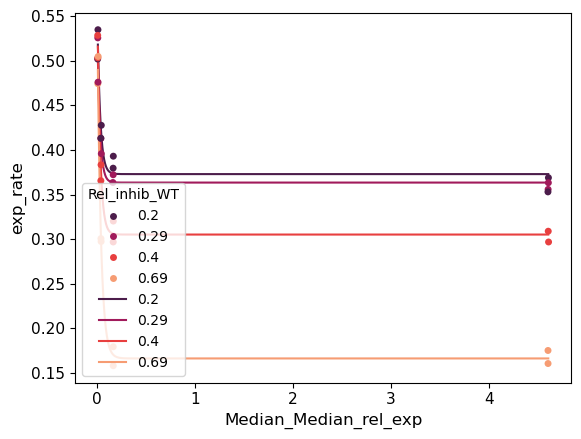

In [696]:
sns.stripplot(data=fc_all_curves, x='Median_Median_rel_exp', y='exp_rate', hue='Rel_inhib_WT', palette='rocket', native_scale=True)
sns.lineplot(data=fit_functions_5FC, x='Median_Median_rel_exp', y='exp_rate', hue='Rel_inhib_WT', palette='rocket')

<Axes: xlabel='Median_Median_rel_exp', ylabel='exp_rate'>

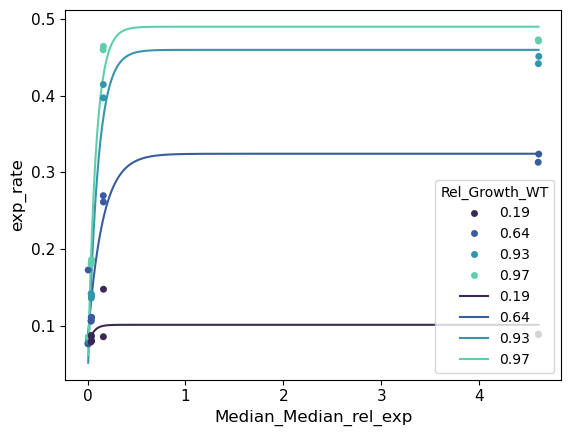

In [698]:
sns.stripplot(data=cyto_all_curves, x='Median_Median_rel_exp', y='exp_rate', hue='Rel_Growth_WT', palette='mako', native_scale=True)
sns.lineplot(data=fit_functions_cyto, x='Median_Median_rel_exp', y='exp_rate', hue='Rel_Growth_WT', palette='mako')

<Axes: xlabel='Median_Median_rel_exp', ylabel='Exp_rel_growth'>

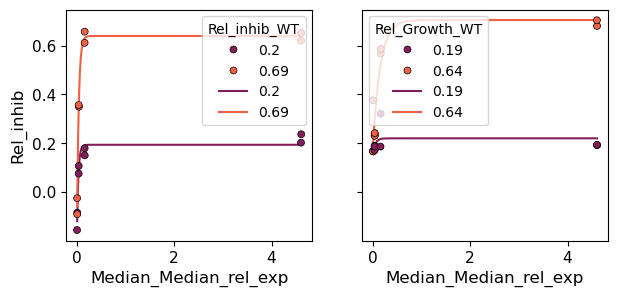

In [720]:
# Comparing the functions side-by-side
data_comp_5FC = fc_all_curves[fc_all_curves['Rel_growth'].isin(fc_comp)].copy().reset_index(drop=True)
fits_comp_5FC = fit_functions_5FC[fit_functions_5FC['Rel_growth'].isin(fc_comp)].copy().reset_index(drop=True)

data_comp_cyto = cyto_all_curves[cyto_all_curves['Rel_growth'].isin(cyto_comp)].copy().reset_index(drop=True)
fits_comp_cyto = fit_functions_cyto[fit_functions_cyto['Rel_growth'].isin(cyto_comp)].copy().reset_index(drop=True)

fig, axs = plt.subplots(1, 2, figsize=(7, 3), sharey=True)

sns.stripplot(data=data_comp_5FC, x='Median_Median_rel_exp', y='Rel_inhib', hue='Rel_inhib_WT', palette='rocket', native_scale=True, ax=axs[0],
             s=5, edgecolor='black', linewidth=0.5)
sns.lineplot(data=fits_comp_5FC, x='Median_Median_rel_exp', y='Rel_inhib', hue='Rel_inhib_WT', palette='rocket', ax=axs[0])

sns.stripplot(data=data_comp_cyto, x='Median_Median_rel_exp', y='Exp_rel_growth', hue='Rel_Growth_WT', palette='rocket', native_scale=True, ax=axs[1],
             s=5, edgecolor='black', linewidth=0.5)
sns.lineplot(data=fits_comp_cyto, x='Median_Median_rel_exp', y='Exp_rel_growth', hue='Rel_Growth_WT', palette='rocket', ax=axs[1])


In [704]:
data_comp_cyto[(data_comp_cyto['Strain'] == 'pTEF1') & (data_comp_cyto['Rel_Growth_WT'] == '0.19')]

,Well,Strain,Clone,Condition,Rel_growth,Max_lin_rate,Max_log_rate,exp_rate,Plate,Cytosine (uM),Log2 cytosine,Inhib_exp,Inhib_lin,Growth_exp,Growth_lin,Median_Median_rel_exp,Min_Median_rel_exp,Max_Median_rel_exp,Exp_rel_growth,Rel_Growth_WT
12,E1,pTEF1,1.0,Cytosine,0.0,0.03,0.120317,0.08816,Cyto-2,3.98494,1.994558,0.191887,0.048387,0.191887,0.048387,4.606104,4.452423,4.730996,0.191887,0.19
14,F1,pTEF1,2.0,Cytosine,0.0,0.02,0.129077,0.08887,Cyto-2,3.98494,1.994558,0.193432,0.032258,0.193432,0.032258,4.606104,4.452423,4.730996,0.193432,0.19


In [679]:
fits_comp_cyto.drop_duplicates()

,Median_Median_rel_exp,exp_rate,Exp_rel_growth,Cytosine (uM),Rel_growth,Rel_Growth_WT
0,0.006689,0.073957,0.160972,3.984940,0.0,0.19
1,0.015906,0.078400,0.170643,3.984940,0.0,0.19
2,0.025123,0.082114,0.178727,3.984940,0.0,0.19
3,0.034341,0.085219,0.185484,3.984940,0.0,0.19
4,0.043558,0.087814,0.191132,3.984940,0.0,0.19
...,...,...,...,...,...,...
995,4.569235,0.324141,0.705513,32.634681,0.1,0.64
996,4.578452,0.324141,0.705513,32.634681,0.1,0.64
997,4.587669,0.324141,0.705513,32.634681,0.1,0.64
998,4.596887,0.324141,0.705513,32.634681,0.1,0.64


In [661]:
cyto_all_curves.columns

Index(['Well', 'Strain', 'Clone', 'Condition', 'Rel_growth', 'Max_lin_rate',
       'Max_log_rate', 'exp_rate', 'Plate', 'Cytosine (uM)', 'Log2 cytosine',
       'Inhib_exp', 'Inhib_lin', 'Growth_exp', 'Growth_lin',
       'Median_Median_rel_exp', 'Min_Median_rel_exp', 'Max_Median_rel_exp',
       'Exp_rel_growth', 'Rel_Growth_WT'],
      dtype='object')

## Asessing the fitness of validation mutants in cytosine

In [418]:
valid_config = pd.read_csv("Valid_mutants_cytosine/Cyto_valid_df.csv")
valid_data1 = pd.read_csv("Valid_mutants_cytosine/FCY1_mutants_cyto_plate1_25-11-27_SA.csv", encoding='unicode_escape')
valid_data2 = pd.read_csv("Valid_mutants_cytosine/FCY1_mutants_cyto_plate2_25-11-27_SA.csv", encoding='unicode_escape')

In [419]:
# Reformatting the growth data
temp_val1 = valid_data1.iloc[0, 1:].copy()  # Separating the temperature timeseries, in case we want to use it later
OD_val1 = valid_data1.iloc[1:, :].copy()
OD_val1 = OD_val1.dropna(subset=['Unnamed: 0']).reset_index(drop=True).copy()
OD_val1 = OD_val1.rename(columns={'Unnamed: 0': 'Well'})

temp_val2 = valid_data2.iloc[0, 1:].copy()  # Separating the temperature timeseries, in case we want to use it later
OD_val2 = valid_data2.iloc[1:, :].copy()
OD_val2 = OD_val2.dropna(subset=['Unnamed: 0']).reset_index(drop=True).copy()
OD_val2 = OD_val2.rename(columns={'Unnamed: 0': 'Well'})


# Reformatting the well column
OD_val1['Well'] = OD_val1['Well'].apply(lambda x: x[0]+'0'+x[1] if len(x)==2 else x)
valid_config['Well'] = valid_config['Well'].apply(lambda x: x[0]+'0'+x[1] if len(x)==2 else x)

OD_val2['Well'] = OD_val2['Well'].apply(lambda x: x[0]+'0'+x[1] if len(x)==2 else x)

In [420]:
# Obtaining blank-adjusted OD data

# Reformatting the df and the 'time' column
OD_val1 = pd.melt(OD_val1, id_vars=['Well'], value_vars=OD_val1.columns[1:], var_name='time', value_name= 'OD')
data_val1 = pd.merge(valid_config, OD_val1, on=['Well'], how='right')
data_val1['time'] = data_val1['time'].apply(lambda x: int(x[:-1]))
data_val1 = data_val1.infer_objects()
data_val1 = data_val1.astype({'OD': 'float64'})
data_val1['time'] = data_val1['time'] / 3600

OD_val2 = pd.melt(OD_val2, id_vars=['Well'], value_vars=OD_val2.columns[1:], var_name='time', value_name= 'OD')

data_val2 = pd.merge(valid_config, OD_val2, on=['Well'], how='right')
data_val2['time'] = data_val2['time'].apply(lambda x: int(x[:-1]))
data_val2 = data_val2.infer_objects()
data_val2 = data_val2.astype({'OD': 'float64'})
data_val2['time'] = data_val2['time'] / 3600

# Normalizing using same-plate blank measurements
# Because the "blank" column was mistakenly inoculated, values from previous TECAN measurements are used
med_blanks = 0.08428125
data_val1['OD_adj'] = data_val1['OD'] - med_blanks

data_val2['OD_adj'] = data_val2['OD'] - med_blanks

In [421]:
# Preparing dfs to store the growth rates
rates_val1 = data_val1[['Well', 'Strain', 'Genotype', 'Condition', 'Rel_growth']].copy().drop_duplicates()
rates_val1 = rates_val1[rates_val1['Strain'] != 'Blank'].copy().reset_index(drop=True)

rates_val2 = data_val2[['Well', 'Strain', 'Genotype', 'Condition', 'Rel_growth']].copy().drop_duplicates()
rates_val2 = rates_val2[rates_val2['Strain'] != 'Blank'].copy().reset_index(drop=True)

In [422]:
# Computing the growth rates, using only blank-adjusted OD data
rates_val1['exp_rate'] = rates_val1['Well'].apply(lambda x: get_log_slope(data_val1, x, 'Well', 'OD_adj', 5, 'time', 2))
rates_val2['exp_rate'] = rates_val2['Well'].apply(lambda x: get_log_slope(data_val2, x, 'Well', 'OD_adj', 5, 'time', 2))

In [423]:
# Concatenating the rates
rates_val1['Plate'] = 'Valid-1'
rates_val2['Plate'] = 'Valid-2'

rates_valid = pd.concat([rates_val1, rates_val2]).reset_index(drop=True)

In [424]:
# Adding the uM cytosine concentrations to all measurements
rates_valid['Cytosine (uM)'] = rates_valid['Rel_growth'].apply(lambda x: cyto_dict[str(x)])

### Adding the WT-relative FCY1 expression level for each mutant

In [426]:
fit_exp_comp = pd.read_csv("Supp_data/growth_exp_val_mutants_reviews.csv")

rates_valid = pd.merge(rates_valid, fit_exp_comp[['Genotype', 'T_insertion_FCY1', 'T_insertion_42-GFP', 
                                                  'Relative_median_exp', 'Max_rel_exp', 'Min_rel_exp',
                                                  'Mutation type', 'In_F3F4', 'FCY1_position']].copy(),
                       on=['Genotype'], how='left')

In [556]:
rates_valid['Relative_median_exp'] = rates_valid['Relative_median_exp'].fillna(1.0)

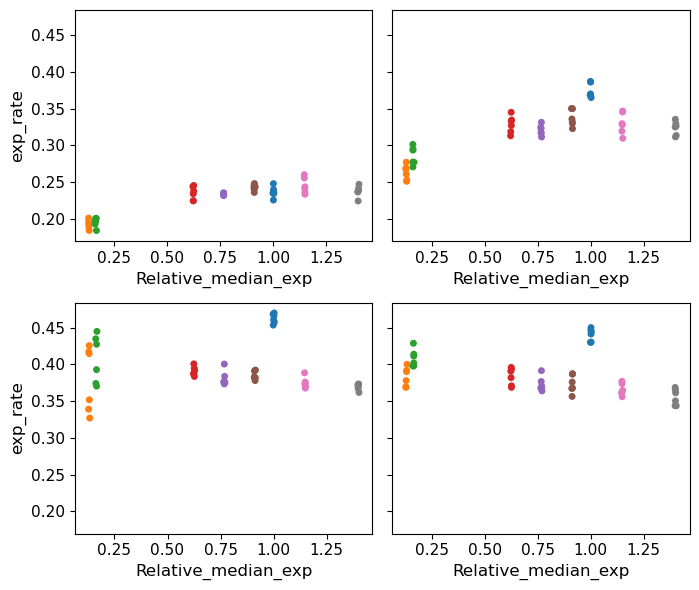

In [558]:
# Trying to plot the growth rates
fig, axs = plt.subplots(2, 2, figsize=(7, 6), sharey=True)

data_ax1 = rates_valid[rates_valid['Rel_growth'] == 0.05].copy().reset_index(drop=True)
sns.stripplot(data=data_ax1, x='Relative_median_exp', y='exp_rate', hue='Strain', ax=axs[0,0], legend=False, native_scale=True)

data_ax2 = rates_valid[rates_valid['Rel_growth'] == 0.10].copy().reset_index(drop=True)
sns.stripplot(data=data_ax2, x='Relative_median_exp', y='exp_rate', hue='Strain', ax=axs[0,1], legend=False, native_scale=True)

data_ax3 = rates_valid[rates_valid['Rel_growth'] == 0.25].copy().reset_index(drop=True)
sns.stripplot(data=data_ax3, x='Relative_median_exp', y='exp_rate', hue='Strain', ax=axs[1,0], legend=False, native_scale=True)

data_ax4 = rates_valid[rates_valid['Rel_growth'] == 0.70].copy().reset_index(drop=True)
sns.stripplot(data=data_ax4, x='Relative_median_exp', y='exp_rate', hue='Strain', ax=axs[1,1], legend=False, native_scale=True)

plt.tight_layout()

C:\Users\tiger\AppData\Local\Temp\ipykernel_39580\354570044.py:6: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.stripplot(data=rates_test, x='Relative_median_exp', y='exp_rate', hue='Rel_growth', palette=cyto_palette, native_scale=True)


<Axes: xlabel='Relative_median_exp', ylabel='exp_rate'>

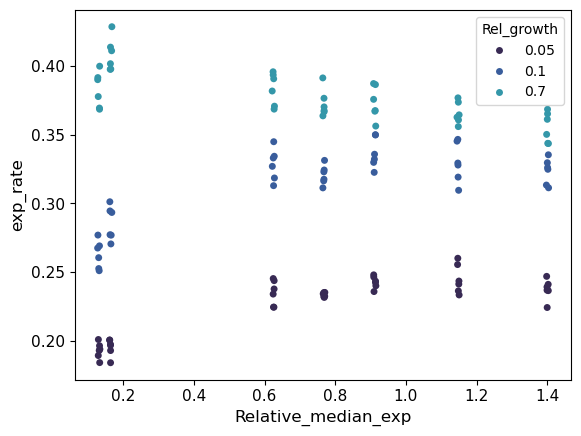

In [571]:
test_rel = [0.05, 0.10, 0.70]
rates_test = rates_valid[rates_valid['Rel_growth'].isin(test_rel)].copy().reset_index(drop=True)
rates_test = rates_test[rates_test['Strain'] != 'AKD1123'].copy().reset_index(drop=True)
cyto_palette = sns.color_palette('mako', 4)

sns.stripplot(data=rates_test, x='Relative_median_exp', y='exp_rate', hue='Rel_growth', palette=cyto_palette, native_scale=True)

This provides evidence that, across a wide range of cytosine concentrations, single promoter mutations increasing expression are not adaptive.

## Comparing the observed DME on fitness with the one expected if changing the expression of FCY1 had the same effect as changing the concentration of 5-FC

In [730]:
# Importing expression estimates for all F3-F4 mutations
exp_predict_df = pd.read_csv('Supp_data/Rel_exp_fcy1_bootstrap.csv')

# Importing all the experimental selection coefficients
s_F3F4 = pd.read_csv('Supp_data/s_300_5FC_no_out.csv')

In [732]:
# Selecting only the median s of F3-F4 mutations
s_meds = s_F3F4[['Genotype', 'Position', 'In F3F4', 'Mutation type', 'Median_s_ignored', 'FCY1_position']].copy().drop_duplicates().reset_index(drop=True)

# Merging expression estimates with info on the mutations
exp_predict_df = pd.merge(exp_predict_df, s_meds, on=['Genotype'], how='left')

# Keeping only the F3-F4 mutations
exp_pred_F3F4 = exp_predict_df[exp_predict_df['In F3F4'] == True].copy().reset_index(drop=True)

In [734]:
# Computing growth rates in 5-FC
# Let's assume exp=1 is [12 uM], the concentration of the screen
exp_pred_F3F4['Pseudo 5-FC (uM)'] = exp_pred_F3F4['Median_rel_exp'] * 12

# Predicting all growth rates based on the fitted logistic model
exp_pred_F3F4['Pred_growth'] = param_5_logit(exp_pred_F3F4['Pseudo 5-FC (uM)'], fit_params_exp[0], fit_params_exp[1], fit_params_exp[2],
                                             fit_params_exp[3], fit_params_exp[4])
growth_WT = param_5_logit(12, fit_params_exp[0], fit_params_exp[1], fit_params_exp[2],
                          fit_params_exp[3], fit_params_exp[4])

# Computing the corresponding selection coefficients
exp_pred_F3F4['s_pred'] = ((exp_pred_F3F4['Pred_growth'] - growth_WT) / growth_WT) * np.log(2)

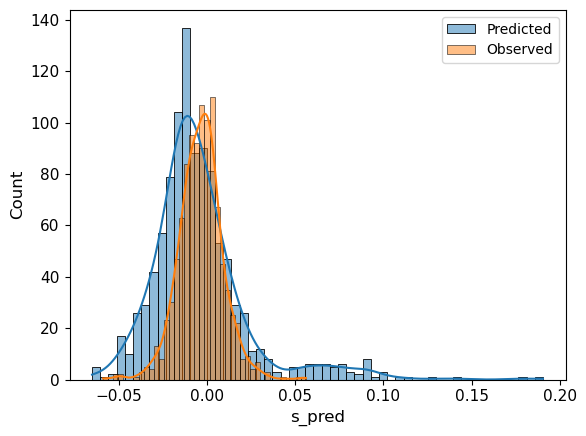

In [736]:
# Plotting the distribution
sns.histplot(data=exp_pred_F3F4, x='s_pred', kde=True, label='Predicted')
sns.histplot(data=exp_pred_F3F4, x='Median_s_ignored', kde=True, label='Observed')
plt.gca().legend()

In [949]:
np.max(exp_pred_F3F4['s_pred'])

0.1904267341006265

In [955]:
np.log2(48)

5.584962500721156

In [738]:
# Exporting a dataframe to add this comparison to "Fig 6"
exp_pred_F3F4.drop(columns=['bot_5percent', 'top_95percent']).to_csv("Supp_data/DFE_comp.csv")

<Axes: xlabel='s_pred', ylabel='Median_s_ignored'>

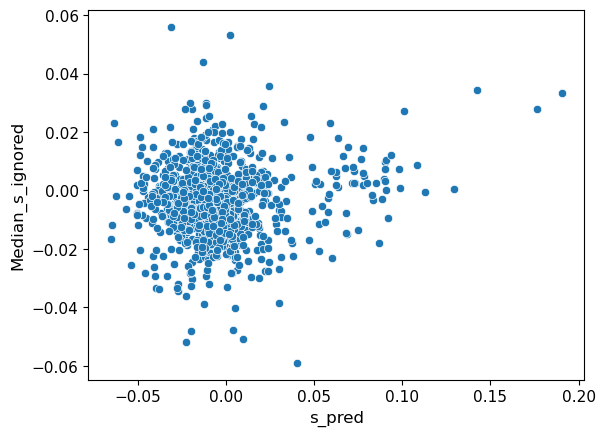

In [537]:
# Looking at the correlation between the two
sns.scatterplot(data=exp_pred_F3F4, x='s_pred', y='Median_s_ignored')

## Assembling the analysis above into one supplementary figure

Everything except the comparison of observed and expected DMEs, which will be added to a main figure

In [767]:
# Reformatting 5-FC and cytosine concentrations
fc_all_curves = fc_all_curves.astype({'5-FC (uM)': 'str'})
fit_functions_5FC = fit_functions_5FC.astype({'5-FC (uM)': 'str'})

cyto_all_curves['Cytosine (uM)'] = cyto_all_curves['Cytosine (uM)'].apply(lambda x: str(round(x, 1)))
fit_functions_cyto['Cytosine (uM)'] = fit_functions_cyto['Cytosine (uM)'].apply(lambda x: str(round(x, 1)))

In [828]:
# Preparing the data for validation mutants in cytosine conditions
valid_rel = [0.05, 0.10, 0.70]
rates_val_plot = rates_valid[rates_valid['Rel_growth'].isin(valid_rel)].copy().reset_index(drop=True)
# Comparing with the WT is not relevant. The adequate control would have been the reconstructed WT clones
# obtained from the same CRISPR approach
rates_val_plot = rates_val_plot[rates_val_plot['Strain'] != 'AKD1123'].copy().reset_index(drop=True)
rates_val_plot['Cytosine (uM)'] = rates_val_plot['Cytosine (uM)'].apply(lambda x: str(round(x, 1)))

# Computing medians for the two mutants closest to WT expression
rates_WT_like = rates_val_plot[rates_val_plot['Genotype'].isin(['S-87_1nt_AtoT', 'S-174_1nt_GtoT'])].copy().reset_index(drop=True)
rates_WT_like = rates_WT_like[['Rel_growth', 'Cytosine (uM)', 'exp_rate']].groupby(by=['Rel_growth', 'Cytosine (uM)'], as_index=False).median()
rates_WT_like = rates_WT_like.sort_values(by='Cytosine (uM)').reset_index(drop=True)

# Defining a common palette for the va mutants
val_palette = sns.color_palette('mako', 3)

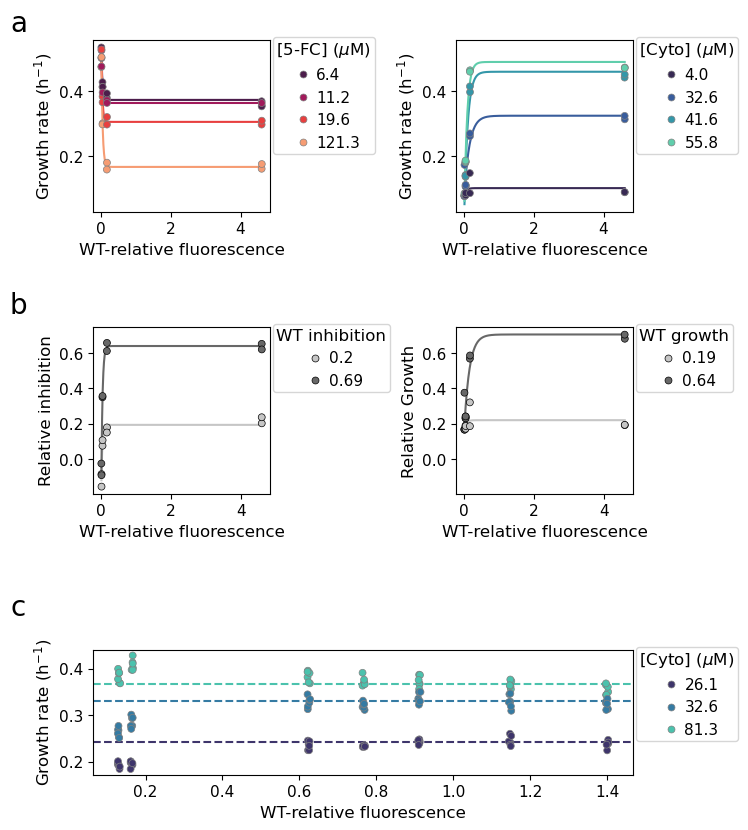

In [880]:
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams['savefig.dpi'] = 600

fig = plt.figure(constrained_layout=False, figsize=(6, 8.5))

# First row, for A
gs1 = fig.add_gridspec(nrows=20, ncols=20, left=0.00, right=1.00, bottom=0.66, top=1.00 )
# Second row, for B
gs2 = fig.add_gridspec(nrows=20, ncols=20, left=0.00, right=1.00, bottom=0.33, top=0.66)
# Third row, for C
gs3 = fig.add_gridspec(nrows=20, ncols=20, left=0.00, right=1.00, bottom=0, top=0.33)

# Defining axes
ax1 = fig.add_subplot(gs1[4:16, 1:7])
ax2 = fig.add_subplot(gs1[4:16, 13:19], sharey=ax1)

ax3 = fig.add_subplot(gs2[4:16, 1:7])
ax4 = fig.add_subplot(gs2[4:16, 13:19], sharey=ax3)

ax5 = fig.add_subplot(gs3[7:16, 1:19])

# Adding plots for panel A
sns.stripplot(data=fc_all_curves, x='Median_Median_rel_exp', y='exp_rate', hue='5-FC (uM)', palette='rocket', native_scale=True, ax=ax1,
             edgecolor='grey', linewidth=0.5)
sns.lineplot(data=fit_functions_5FC, x='Median_Median_rel_exp', y='exp_rate', hue='5-FC (uM)', palette='rocket', ax=ax1, legend=False)
ax1.legend(loc='upper left', title=r"[5-FC] ($\mu$M)", title_fontsize=12,
           bbox_to_anchor=(1.02, 1.01), fontsize=11, borderaxespad=-0.05, borderpad=0.25, handletextpad=-0.1)
ax1.set_ylabel(r"Growth rate (h$^{-1}$)")

sns.stripplot(data=cyto_all_curves, x='Median_Median_rel_exp', y='exp_rate', hue='Cytosine (uM)', palette='mako', native_scale=True, ax=ax2,
             edgecolor='grey', linewidth=0.5)
sns.lineplot(data=fit_functions_cyto, x='Median_Median_rel_exp', y='exp_rate', hue='Cytosine (uM)', palette='mako', ax=ax2, legend=False)
ax2.legend(loc='upper left', title=r"[Cyto] ($\mu$M)", title_fontsize=12,
           bbox_to_anchor=(1.02, 1.01), fontsize=11, borderaxespad=-0.05, borderpad=0.25, handletextpad=-0.1)
ax2.set_ylabel(r"Growth rate (h$^{-1}$)")

# Adding plots for panel B
sns.stripplot(data=data_comp_5FC, x='Median_Median_rel_exp', y='Rel_inhib', hue='Rel_inhib_WT', palette='Greys', native_scale=True, ax=ax3,
              s=5, edgecolor='black', linewidth=0.5)
sns.lineplot(data=fits_comp_5FC, x='Median_Median_rel_exp', y='Rel_inhib', hue='Rel_inhib_WT', palette='Greys', ax=ax3, legend=False)
ax3.legend(loc='upper left', title=r"WT inhibition", title_fontsize=12,
           bbox_to_anchor=(1.02, 1.01), fontsize=11, borderaxespad=-0.05, borderpad=0.25, handletextpad=-0.1)
ax3.set_ylabel('Relative inhibition')

sns.stripplot(data=data_comp_cyto, x='Median_Median_rel_exp', y='Exp_rel_growth', hue='Rel_Growth_WT', palette='Greys', native_scale=True, ax=ax4,
             s=5, edgecolor='black', linewidth=0.5)
sns.lineplot(data=fits_comp_cyto, x='Median_Median_rel_exp', y='Exp_rel_growth', hue='Rel_Growth_WT', palette='Greys', ax=ax4, legend=False)
ax4.legend(loc='upper left', title=r"WT growth", title_fontsize=12,
           bbox_to_anchor=(1.02, 1.01), fontsize=11, borderaxespad=-0.05, borderpad=0.25, handletextpad=-0.1)
ax4.set_ylabel('Relative Growth')

# Adding the plot for panel C
sns.stripplot(data=rates_val_plot, x='Relative_median_exp', y='exp_rate', hue='Cytosine (uM)', palette=val_palette, native_scale=True, ax=ax5,
             edgecolor='grey', linewidth=0.5)
ax5.legend(loc='upper left', title=r"[Cyto] ($\mu$M)", title_fontsize=12,
           bbox_to_anchor=(1.02, 0.96), fontsize=11, borderaxespad=-0.525, borderpad=0.25, handletextpad=-0.1)
for row_id in rates_WT_like.index:
    ax5.axhline(y=rates_WT_like.at[row_id, 'exp_rate'], c=val_palette[row_id], linestyle='--')
ax5.set_ylabel(r"Growth rate (h$^{-1}$)")

for ax in [ax1, ax2, ax3, ax4, ax5]:
    ax.set_xlabel("WT-relative fluorescence")

# Identifying the plots
ax1.annotate('a', (-60, 130), xycoords='axes points', annotation_clip=False, fontsize=20)
ax3.annotate('b', (-60, 130), xycoords='axes points', annotation_clip=False, fontsize=20)
ax5.annotate('c', (-60, 115), xycoords='axes points', annotation_clip=False, fontsize=20)

fig = plt.gcf()
fig.savefig(f"Supp_figs/FCvsCyto_adapt.tiff", bbox_inches='tight')